<a href="https://colab.research.google.com/github/00015775/learning-lab/blob/learn%2Fpytorch/pytorch/notebooks/02_youtube_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Saving PyTorch model

In [1]:
# stopped at 7:22

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() \
                      else "mps" if torch.backends.mps.is_available()\
                      else "cpu")

In [4]:
from pathlib import Path

torch.manual_seed(42)

SAVE_MODEL_DIR = Path("./models")
SAVE_MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "model.pth"
MODEL_SAVE_PATH = SAVE_MODEL_DIR / MODEL_NAME # forward slash like unix

model = nn.Linear(1,1) # one neuron for each layer
model.to("cpu") # make sure save on CPU for OS agnostic purposes

torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)

In [5]:
model.state_dict() # weights and biases are randomly initialized

OrderedDict([('weight', tensor([[0.7645]])), ('bias', tensor([0.8300]))])

In [6]:
!ls -l ./models/ && echo && du -h ./models/

total 4
-rw-r--r-- 1 root root 1877 Jan 27 14:49 model.pth

8.0K	./models/


In [7]:
# if saved on GPU, it will try to load on GPU, but if
# other computer does not have a GPU, then it will throw an error
# make sure to make it OS agnostic by saving on CPU

In [8]:
# create an instance of the same model in order for architeture to match
# and be able to load into it
loaded_model_0 = nn.Linear(1,1)

loaded_model_0

Linear(in_features=1, out_features=1, bias=True)

In [9]:
print(MODEL_SAVE_PATH)

models/model.pth


In [10]:
loaded_model_0.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [11]:
model.state_dict()

OrderedDict([('weight', tensor([[0.7645]])), ('bias', tensor([0.8300]))])

In [12]:
loaded_model_0.state_dict()

OrderedDict([('weight', tensor([[0.7645]])), ('bias', tensor([0.8300]))])

In [13]:
model.state_dict() == loaded_model_0.state_dict()

True

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:132: UserWarning: Using a target size (torch.Size([5, 1])) that is different to the input size (torch.Size([4, 5, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


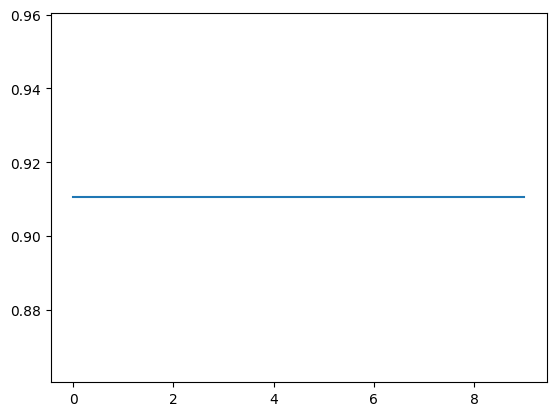

In [14]:
import matplotlib.pyplot as plt


x_test = torch.randn(4,5,1)
y_test = x_test[-1]
loaded_model_0.to(device)
loaded_model_0.eval()
test_loss = []
loss_fn = nn.L1Loss()

with torch.inference_mode():
  for i in range(10):
    output = loaded_model_0(x_test)
    loss = loss_fn(output, y_test)
    test_loss.append(loss.item())

plt.plot(test_loss)
plt.show()

In [15]:
torch.__version__

'2.9.0+cpu'

In [16]:
weight = 0.7
bias = 0.3

X = torch.arange(0, 1, 0.02).unsqueeze(dim=1)
y = weight * X + bias

X.shape, y.shape

(torch.Size([50, 1]), torch.Size([50, 1]))

In [17]:
linear_model = nn.Linear(1,1)

print(linear_model.state_dict())

OrderedDict({'weight': tensor([[0.2687]]), 'bias': tensor([-0.2712])})


In [18]:
# stopped at 9:00

## NN

In [19]:
import sklearn
from sklearn.datasets import make_circles

In [20]:
n_samples = 1000

X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [21]:
X.shape, y.shape # (1000=examples, 2=features)

((1000, 2), (1000,))

In [22]:
len(X), len(y)

(1000, 1000)

In [23]:
type(X), type(y)

(numpy.ndarray, numpy.ndarray)

In [24]:
display(X[:5], y[:5])

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       [-0.39373073,  0.69288277],
       [ 0.44220765, -0.89672343]])

array([1, 1, 1, 1, 0])

In [25]:
y # binary classification

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [26]:
X # input features

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [27]:
import pandas as pd

circles = pd.DataFrame({"X1": X[:, 0],  # first column
                        "X2": X[:, 1],  # second column
                        "label": y})    # target label

In [28]:
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [29]:
len(circles) # 1000 rows/examples/instances

1000

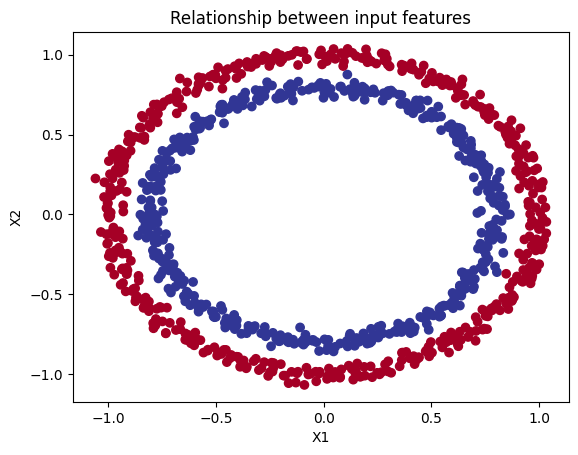

In [30]:
import matplotlib.pyplot as plt

plt.scatter(x=X[:, 0], # first column
            y=X[:, 1], # second column
            c=y,
            cmap=plt.cm.RdYlBu)

plt.xlabel('X1')
plt.ylabel('X2')
plt.title("Relationship between input features")
plt.show()

# relationship between input features

In [31]:
circles.describe()

,X1,X2,label
count,1000.000000,1000.000000,1000.00000
mean,-0.000448,-0.000804,0.50000
std,0.639837,0.641156,0.50025
min,-1.059502,-1.067768,0.00000
25%,-0.619251,-0.612176,0.00000
50%,0.008762,-0.003949,0.50000
75%,0.621933,0.624822,1.00000
max,1.033712,1.036004,1.00000


## Check input and output shapes

In [32]:
circles["X1"].shape, circles["X2"].shape, circles["label"].shape

((1000,), (1000,), (1000,))

In [33]:
X_sample = X[0] # first row
y_sample = y[0] # first row

print(f"one sample for X={X_sample}, shape={X_sample.shape}")
print(f"one sample for y={y_sample}, shape={y_sample.shape}")

one sample for X=[0.75424625 0.23148074], shape=(2,)
one sample for y=1, shape=()


## Turn data into Tensors

In [34]:
import torch
torch.__version__

'2.9.0+cpu'

In [35]:
type(X), type(y), X.dtype, y.dtype

(numpy.ndarray, numpy.ndarray, dtype('float64'), dtype('int64'))

In [36]:
X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

In [37]:
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [38]:
X.dtype, y.dtype

(torch.float32, torch.float32)

In [39]:
type(X), type(y)

(torch.Tensor, torch.Tensor)

# Splitting dataset

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, # 80% for train
                                                    shuffle=True,
                                                    random_state=42)


In [41]:
len(X_train), len(X_test)

(800, 200)

In [42]:
len(y_train), len(y_test)

(800, 200)

In [43]:
X_train.shape, X_test.shape

(torch.Size([800, 2]), torch.Size([200, 2]))

In [44]:
y_train.shape, y_test.shape

(torch.Size([800]), torch.Size([200]))

In [45]:
# stoped at 9:22

## Building a model

In [57]:
import torch
import torch.nn as nn


device = torch.device("cuda" if torch.cuda.is_available() else\
                      "mps" if torch.backends.mps.is_available() else\
                      "cpu")

device

device(type='cpu')

In [58]:
X_train.device, y_train.device

(device(type='cpu'), device(type='cpu'))

In [62]:
!pip install torchviz

In [72]:
from torchviz import make_dot
import matplotlib.image as mpimg

In [73]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1) # treat as output layer for now


  def forward(self, x):
    return self.layer_2(self.layer_1(x))


model_0 = CircleModelV0().to(device)

model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [75]:
dummy_input = torch.randn(1000, 2)

outputing = model_0(dummy_input)

dot = make_dot(outputing, params=dict(model_0.named_parameters()))
dot.render("model_0_diagram", format="png")

'model_0_diagram.png'

In [77]:
next(model_0.parameters()).device

device(type='cpu')

In [85]:
from collections import OrderedDict

class CircleModelSeq(nn.Module):
  def __init__(self):
    super().__init__()
    self.two_linear_layers = nn.Sequential(
        nn.Linear(2, 5),
        nn.Linear(5, 1)
    )


  def forward(self, x):
    return self.two_linear_layers(x)


model_0 = CircleModelSeq().to(device)

model_0

CircleModelSeq(
  (two_linear_layers): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Linear(in_features=5, out_features=1, bias=True)
  )
)

In [86]:
model_0.state_dict()

OrderedDict([('two_linear_layers.0.weight',
              tensor([[ 0.3132, -0.2136],
                      [ 0.4624,  0.0653],
                      [ 0.2490,  0.0753],
                      [-0.6627, -0.1066],
                      [-0.3883, -0.2801]])),
             ('two_linear_layers.0.bias',
              tensor([ 0.5690, -0.5472, -0.5163, -0.2268, -0.3138])),
             ('two_linear_layers.1.weight',
              tensor([[0.1104, 0.2870, 0.0702, 0.0079, 0.2148]])),
             ('two_linear_layers.1.bias', tensor([0.2671]))])

In [91]:
for name, val in model_0.named_parameters():
  print(name, val.shape)

two_linear_layers.0.weight torch.Size([5, 2])
two_linear_layers.0.bias torch.Size([5])
two_linear_layers.1.weight torch.Size([1, 5])
two_linear_layers.1.bias torch.Size([1])


In [106]:
criterion = nn.L1Loss()

with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
  loss = criterion(untrained_preds, y_test)

print(loss)

tensor(0.5061)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:132: UserWarning: Using a target size (torch.Size([200])) that is different to the input size (torch.Size([200, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


In [98]:
untrained_preds.shape, X_test.shape, y_test.shape

(torch.Size([200, 1]), torch.Size([200, 2]), torch.Size([200]))

In [100]:
y_test[:10]

tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])

In [101]:
untrained_preds[:10]

tensor([[-0.0100],
        [ 0.0108],
        [ 0.0189],
        [-0.0185],
        [ 0.1511],
        [ 0.1628],
        [ 0.1164],
        [ 0.1523],
        [ 0.0133],
        [ 0.0136]])

## Loss function and optimizer

In [110]:
nn.Sequential(
    nn.Sigmoid(),
    nn.BCELoss()
)

loss_fn = nn.BCEWithLogitsLoss() # nn.Sigmoid() + nn.BCELoss()

optimizer = torch.optim.SGD(model_0.parameters(),
                            lr=0.001)


In [111]:
model_0.state_dict()

OrderedDict([('two_linear_layers.0.weight',
              tensor([[ 0.3132, -0.2136],
                      [ 0.4624,  0.0653],
                      [ 0.2490,  0.0753],
                      [-0.6627, -0.1066],
                      [-0.3883, -0.2801]])),
             ('two_linear_layers.0.bias',
              tensor([ 0.5690, -0.5472, -0.5163, -0.2268, -0.3138])),
             ('two_linear_layers.1.weight',
              tensor([[0.1104, 0.2870, 0.0702, 0.0079, 0.2148]])),
             ('two_linear_layers.1.bias', tensor([0.2671]))])

In [112]:
optimizer.state_dict()

{'state': {},
 'param_groups': [{'lr': 0.001,
   'momentum': 0,
   'dampening': 0,
   'weight_decay': 0,
   'nesterov': False,
   'maximize': False,
   'foreach': None,
   'differentiable': False,
   'fused': None,
   'params': [0, 1, 2, 3]}]}

In [113]:
# Accuracy: (TF + TN) / (TF + TN + FP + FN)

def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc

In [114]:
# stopped at 10:11